In [1]:
import torchvision
import torch
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
#27a06543555c34be2ac8229a9ba1dc2a993596c56d2c5c05


In [ ]:

class ResNetBlock(nn.Module):
    def __init__(self, start, end=None):
        super().__init__()
        
        # If end is given, it's a downsampling block with skip connection
        if end is not None:
            self.block = nn.Sequential(
                nn.Conv2d(start, end, kernel_size=3, stride=2, padding=1, bias=False),
                nn.BatchNorm2d(end),
                nn.ReLU(inplace=True),
                nn.Conv2d(end, end, kernel_size=3, stride=1, padding=1, bias=False),
                nn.BatchNorm2d(end),
            )
            self.skip = nn.Sequential(
                nn.Conv2d(start, end, kernel_size=1, stride=2, bias=False),
                nn.BatchNorm2d(end),
            )
        else:
            # Identity block (no change in number of channels or resolution)
            self.block = nn.Sequential(
                nn.Conv2d(start, start, kernel_size=3, stride=1, padding=1, bias=False),
                nn.BatchNorm2d(start),
                nn.ReLU(inplace=True),
                nn.Conv2d(start, start, kernel_size=3, stride=1, padding=1, bias=False),
                nn.BatchNorm2d(start),
            )
            self.skip = None  # Explicitly mark no skip layer

    def forward(self, x):
        identity = x if self.skip is None else self.skip(x)
        out = self.block(x)
        return F.relu(out + identity)


class ResNet18(nn.Module):
    def __init__(self):
        super().__init__()

        # Initial stem conv layer
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )

        self.max_pool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # Define the ResNet layers
        self.conv2 = nn.Sequential(
            ResNetBlock(64),
            ResNetBlock(64)
        )
        self.conv3 = nn.Sequential(
            ResNetBlock(64, 128),
            ResNetBlock(128)
        )
        self.conv4 = nn.Sequential(
            ResNetBlock(128, 256),
            ResNetBlock(256)
        )
        self.conv5 = nn.Sequential(
            ResNetBlock(256, 512),
            ResNetBlock(512)
        )

        # Global average pooling and classification head
        self.average_pool = nn.AdaptiveAvgPool2d((1, 1))  # More flexible than fixed 7x7
        self.fully_connected = nn.Linear(512, 400)

    def forward(self, x):
        x = self.conv1(x)
        x = self.max_pool(x)

        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)

        x = self.average_pool(x)
        x = torch.flatten(x, 1)  # Flatten all dimensions except batch
        return self.fully_connected(x)


# Loading the data

We will use a bird dataset, where the task is to classify each image into one of 400 different classes of birds.

## Download the data

In [3]:
#!uv add gdown

In [4]:
!ls dl

bird_data  segmentdata.zip


## Data Loader

* PyTorch typically uses Dataset and DataLoader classes to load data during training. The DataLoader enables processing data on multiple cores (num_workers argument), which is useful as the data loading speed is commonly the bottleneck in network training.

* The batch size used during training is also usually an argument of the DataLoader.

* We will be using the torchvision.datasets.ImageFolder class that can easily load images that have been separated into individual folders by class. The data loader then outputs the data in the form of (image, label) pairs. For tasks other than classification, custom dataset classes are more common.

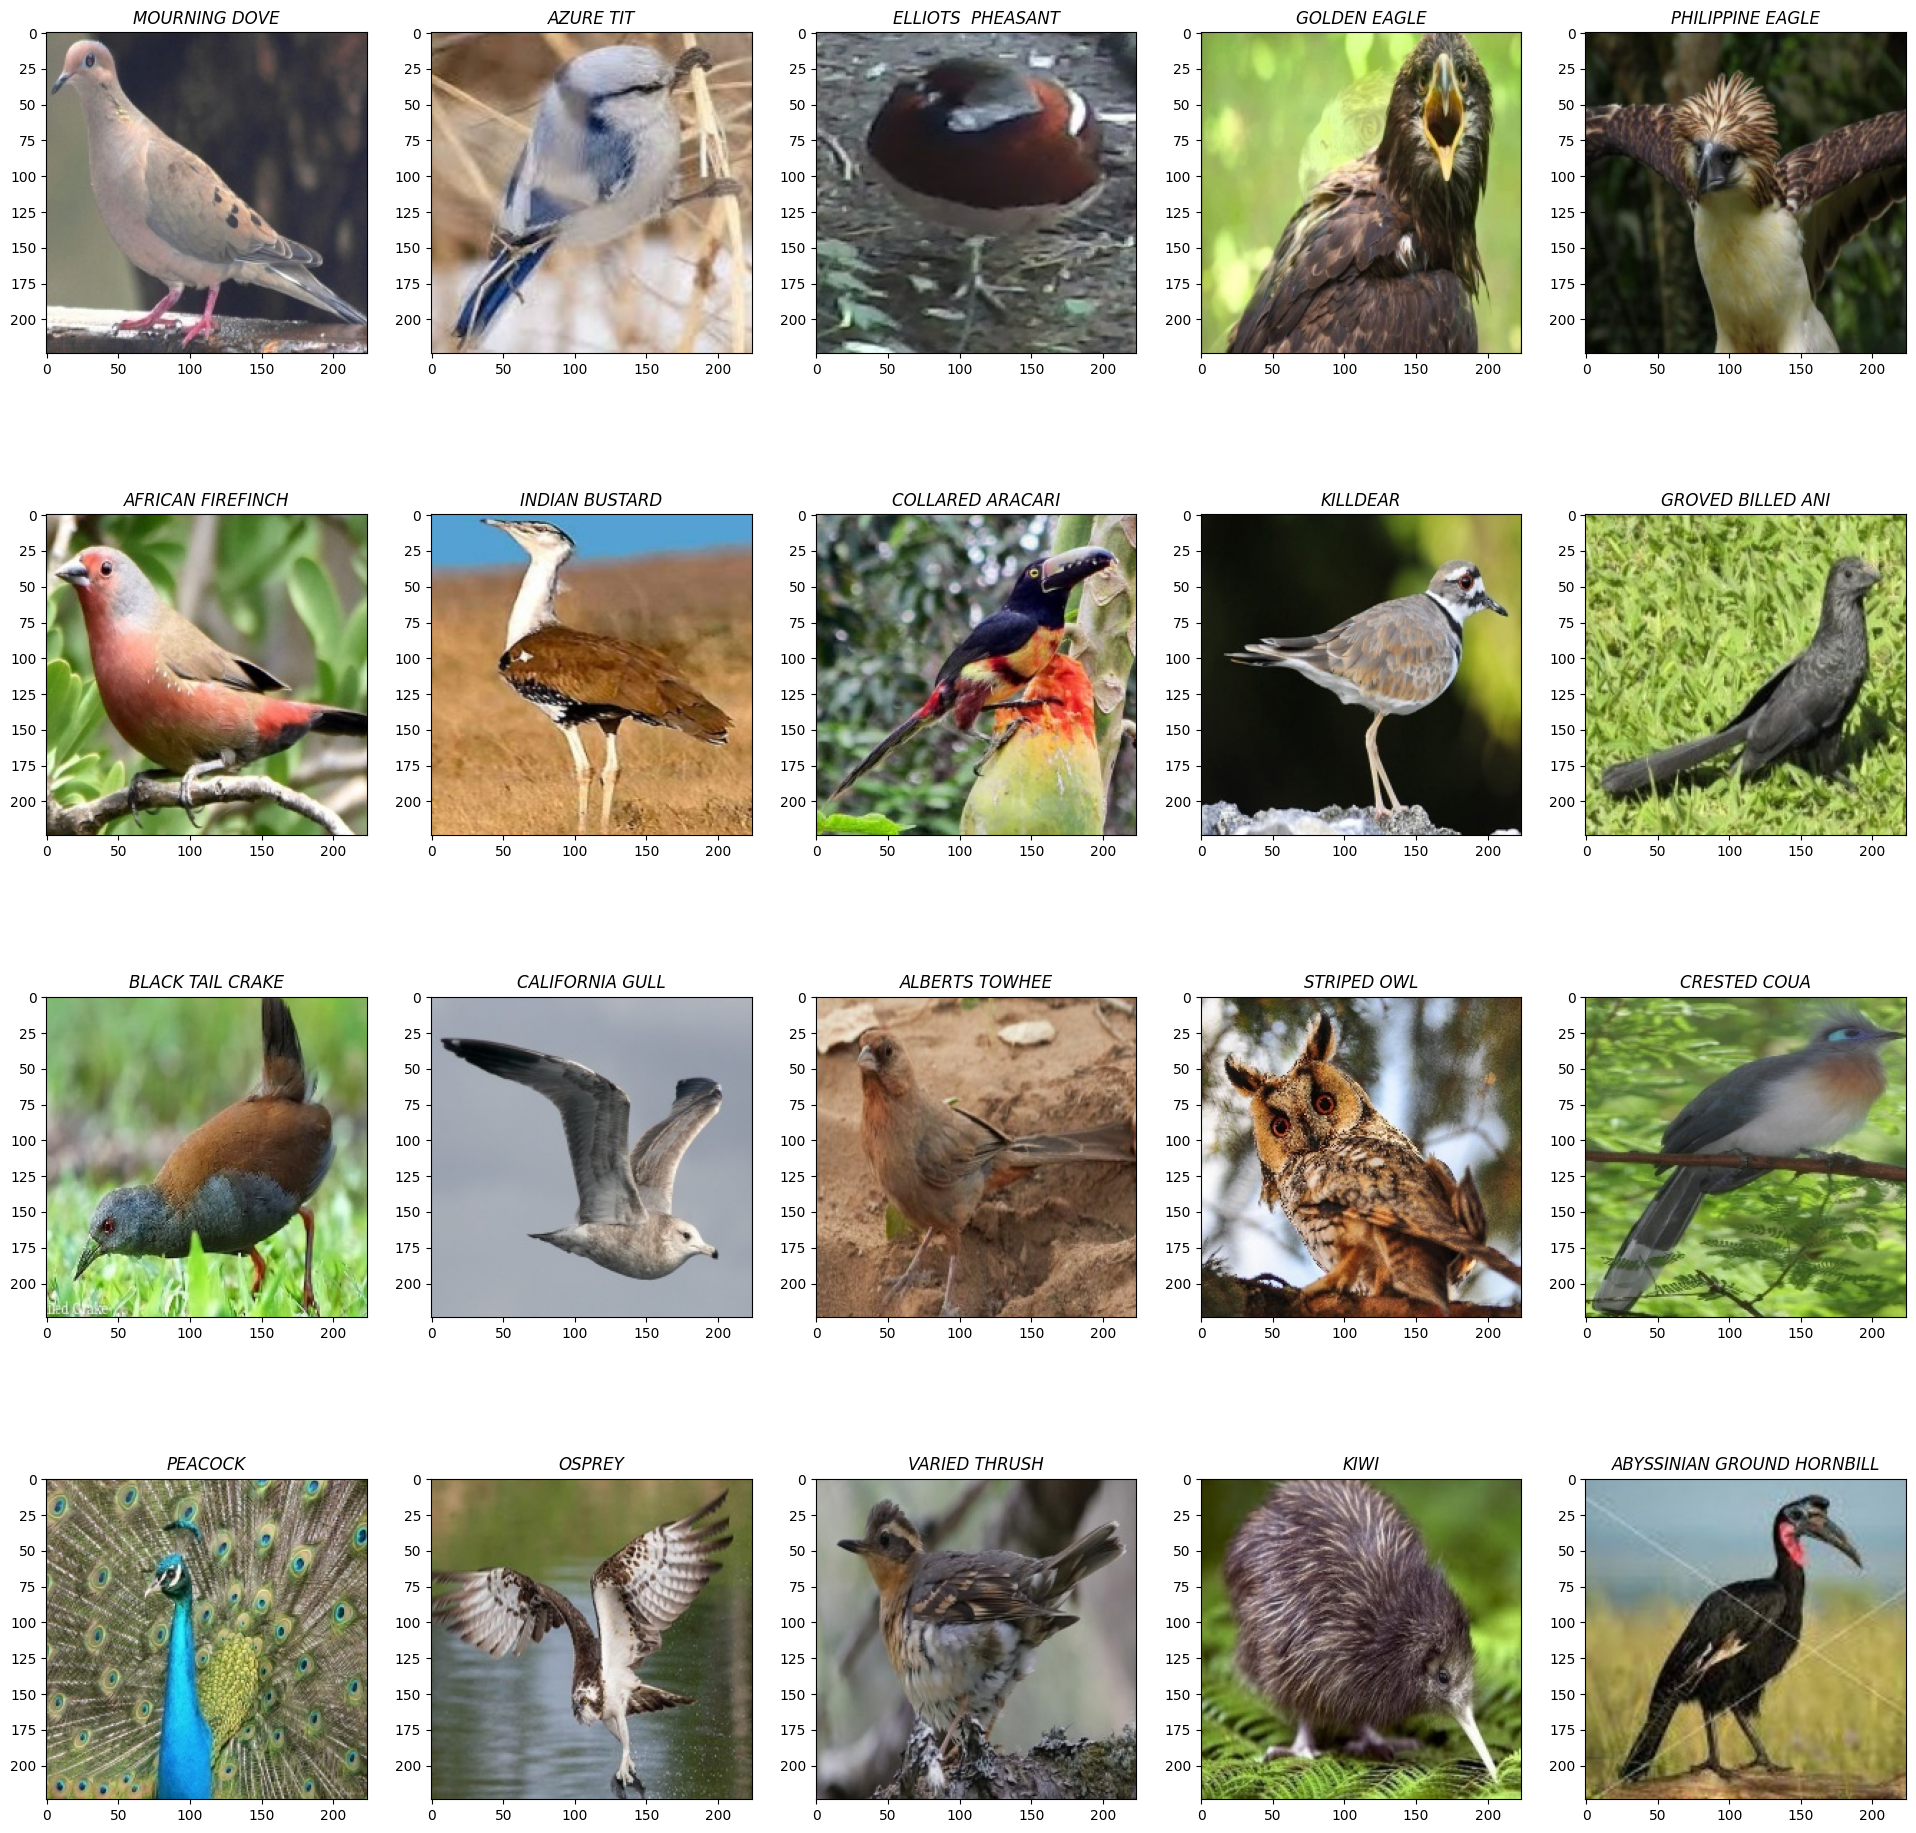

In [5]:

from pathlib import Path
data = Path("dl") / "bird_data"
# so that it works correctly on remote jupyter server


batch_size = 24
# Transforms can also be used for image augmentation - https://pytorch.org/vision/stable/transforms.html
transform = transforms.Compose(
    [
    transforms.ToTensor()
    ])


trainset = torchvision.datasets.ImageFolder(root=data / "train",transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=0)

testset = torchvision.datasets.ImageFolder(root=data / "test", transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=0)

valset = torchvision.datasets.ImageFolder(root=data / "valid",transform=transform)
valloader = torch.utils.data.DataLoader(valset, batch_size=batch_size,
                                          shuffle=True, num_workers=0)


# Displaying random trainset images
import matplotlib.pyplot as plt
import numpy as np
fig=plt.figure(figsize=(24, 24))
columns = 5
rows = 4
for i in range(columns*rows):
  input, label = trainset[np.random.randint(len(trainset))]
  #print(input.shape)
  img = input.detach().numpy().transpose((1,2,0))
  ax = fig.add_subplot(rows, columns, i+1)
  ax.set_title(trainset.classes[label], fontstyle='italic')
  plt.imshow(img)
plt.show()



## Training the network

The training parameters (learning rate, batch size, optimizer choice etc.) are not fine-tuned. Feel free to optimize the parameters further to improve the results.

In [6]:
import torch.optim as optim
from tqdm import tqdm

def test_bird_model(net, curr_data_loader, val_test="val"):
    # Testing

    criterion = nn.CrossEntropyLoss()

    num_images = len(curr_data_loader.dataset)
    gt_array = np.zeros(num_images)
    pred_array = np.zeros(num_images)

    correct = 0
    total = 0
    running_loss = 0.0
    net.eval()
    with torch.no_grad():
        for i,data in enumerate(curr_data_loader):
            images, labels = data
            images = images.cuda()
            labels = labels.cuda()

            outputs = net(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            gt_array[i*labels.size(0):(i+1)*labels.size(0)] = labels.detach().cpu().numpy()
            pred_array[i*labels.size(0):(i+1)*labels.size(0)] = predicted.detach().cpu().numpy()

    print('Accuracy of the network on %s images: %d %%' % (val_test,
            100 * correct / total))
    print("Test loss: "+str(running_loss/(total/4)))
    return gt_array, pred_array

def train_bird_model(epochs, lr):
    # Use the ResNet18 when implemented
    net = ResNet18()
    #net = ExampleNet()
    net.cuda()

    # Define the loss function
    criterion = nn.CrossEntropyLoss()

    # Initialize the optimizer
    optimizer = optim.Adam(net.parameters(), lr=lr)

    for epoch in range(epochs):
        with tqdm(total=len(trainset), desc ='Epoch: '+str(epoch)+"/"+str(epochs), unit='img') as prog_bar:
            for i, data in enumerate(trainloader, 0):
                # Get the inputs; Data is a tuple of (images, labels)
                inputs, labels = data
                # Transfer the images and labels to the GPU.
                inputs = inputs.cuda()
                labels = labels.cuda()

                # Clear the saved gradients of the previous iteration
                optimizer.zero_grad()

                outputs = net(inputs)
                # Calculate the loss value
                loss = criterion(outputs, labels)
                # Calculate the gradients using backpropagation
                loss.backward()
                # Update the weights of the network using the chosen optimizer
                optimizer.step()

                prog_bar.set_postfix(**{'loss': loss.data.cpu().detach().numpy()})
                prog_bar.update(batch_size)

        if epoch % 5 == 0:
            test_bird_model(net, valloader)
            net.train()
    test_bird_model(net,testloader)

    return net




## Run training

In [7]:
net = train_bird_model(20,0.001)

Epoch: 0/20:   0%|          | 0/58388 [00:00<?, ?img/s]

Epoch: 0/20: 58392img [04:00, 242.44img/s, loss=4.1371737]                          


Accuracy of the network on val images: 16 %
Test loss: 0.63485213804245


Epoch: 2/20: 58392img [03:59, 243.71img/s, loss=1.4731619]                           
Epoch: 3/20: 58392img [04:00, 242.54img/s, loss=0.7796929]                           
Epoch: 4/20: 58392img [03:58, 244.55img/s, loss=0.2449828]                           
Epoch: 5/20: 58392img [04:00, 243.09img/s, loss=0.9788766]                            


Accuracy of the network on val images: 85 %
Test loss: 0.10125868161767722


...

Accuracy of the network on val images: 85 %
Test loss: 0.11114906544983387


Epoch: 12/20: 58392img [04:05, 238.33img/s, loss=0.02873995]                            
Epoch: 13/20: 58392img [07:01, 138.51img/s, loss=0.0072639263]                           
Epoch: 14/20: 58392img [08:02, 121.05img/s, loss=0.027189061]                            
Epoch: 15/20: 58392img [08:05, 120.31img/s, loss=0.08780151]                             


Accuracy of the network on val images: 87 %
Test loss: 0.10244700711965561


Epoch: 16/20:  37%|███▋      | 21408/58388 [02:57<05:09, 119.38img/s, loss=0.0101367]    IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

Epoch: 16/20: 58392img [08:03, 120.78img/s, loss=0.031205025]                           
Epoch: 17/20: 58392img [06:24, 152.05img/s, loss=0.022093391]                            
Epoch: 18/20: 58392img [05:21, 181.86img/s, loss=0.06921726]                             
Epoch: 19/20: 58392img [07:24, 131.49img/s, loss=0.11715231]                             


Accuracy of the network on val images: 90 %
Test loss: 0.06673592767398805


## Run Test and visualize classification errors



Accuracy of the network on val images: 90 %
Test loss: 0.06673592767398805


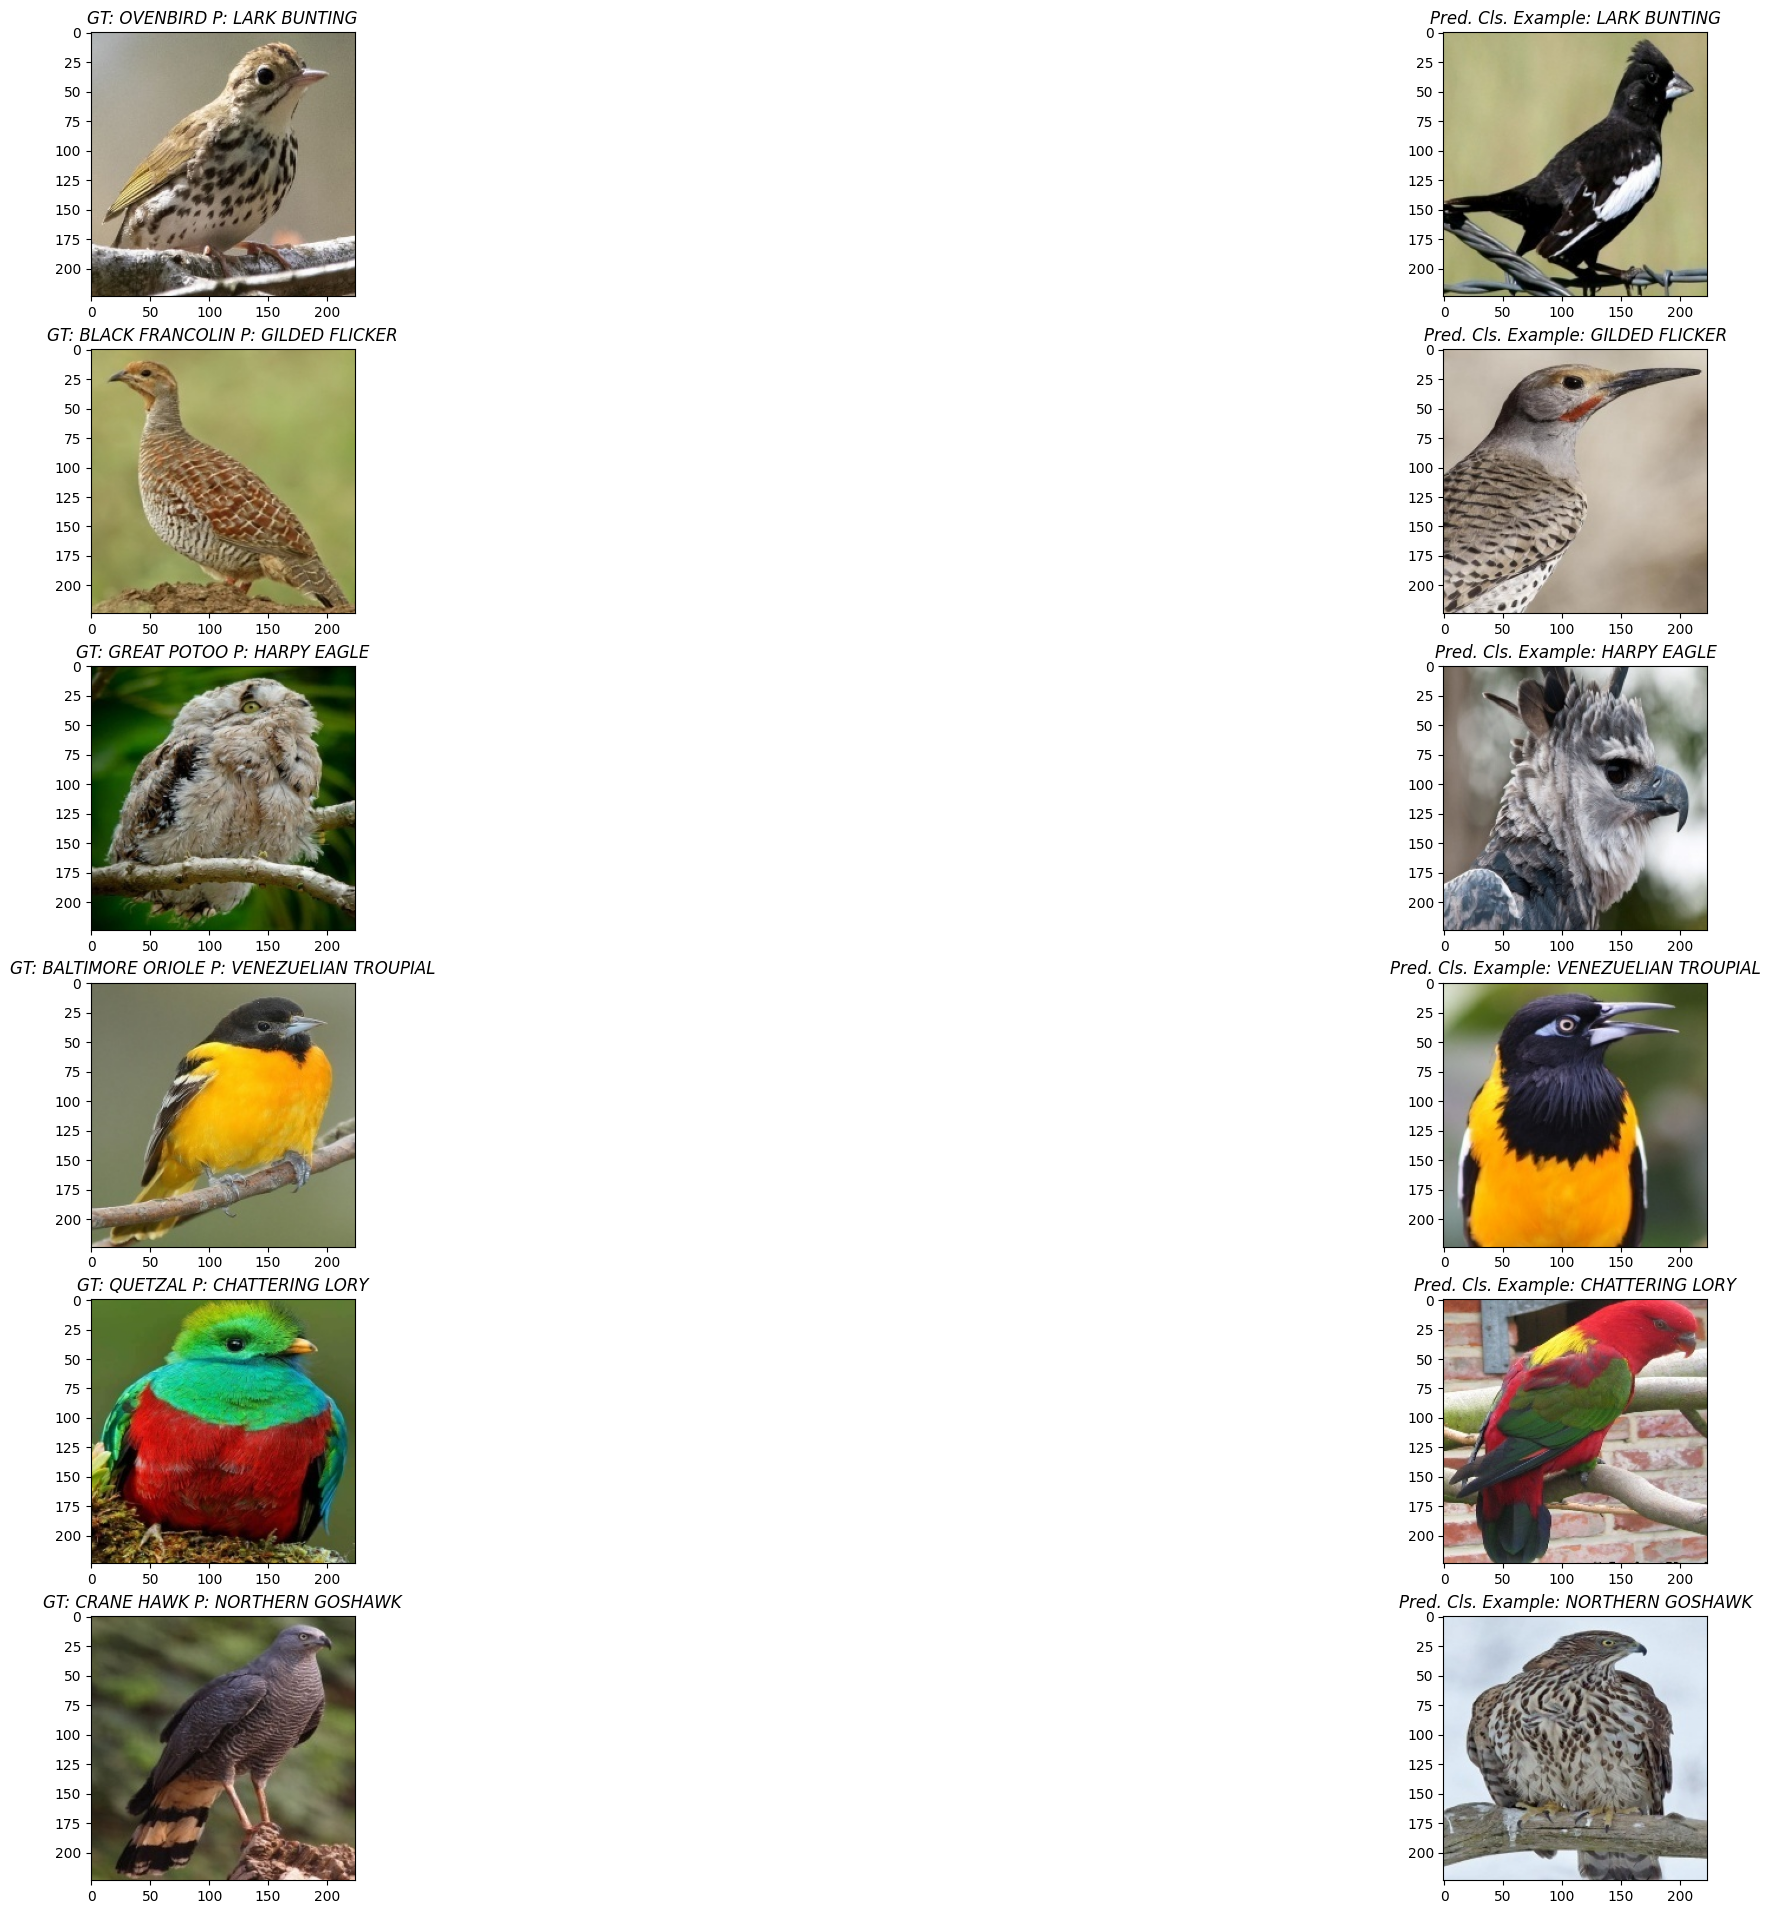

In [14]:
gt_array, pred_array = test_bird_model(net,testloader)

# Displaying random misclassified images
fig=plt.figure(figsize=(32, 24))
columns = 2
rows = 6
mistake_indices = np.nonzero(gt_array != pred_array)[0]
for i in range(rows):
  chosen_index = mistake_indices[np.random.randint(len(mistake_indices))]
  input, label = testset[chosen_index]
  pred_label = pred_array[chosen_index].astype(np.int32)
  pred_cls_samples = np.nonzero(gt_array == pred_label)[0]
  pred_cls_input, _ = testset[pred_cls_samples[np.random.randint(len(pred_cls_samples))]]


  img = input.detach().numpy().transpose((1,2,0))
  ax = fig.add_subplot(rows, columns, columns*i+1)
  im_title = "GT: "+trainset.classes[label] + " P: "+trainset.classes[pred_label]
  ax.set_title(im_title, fontstyle='italic')
  plt.imshow(img)

  img_sample = pred_cls_input.detach().numpy().transpose((1,2,0))
  ax = fig.add_subplot(rows, columns, columns*i+2)
  im_title = "Pred. Cls. Example: "+trainset.classes[pred_label]
  ax.set_title(im_title, fontstyle='italic')
  plt.imshow(img_sample)

plt.show()
